In [11]:
# Import the required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# First load the data
data = pd.read_excel('difference in prices between exchanges.xlsx')

In [23]:
# View the head
data.head()

,date,startTime,endTime,sym,lastPrice,exchange
0,2025-02-01,2025-02-01 00:00:00.000000000,2025-03-03 00:00:00.000000000,BTCUSD,91526.000000,bitstamp
1,2025-02-01,2025-02-01 00:00:00.000000000,2025-03-03 00:00:00.000000000,BTCUSD,95609.159600,bullish
2,2025-02-01,2025-02-01 00:00:00.000000000,2025-03-03 00:00:00.000000000,BTCUSD,91531.910000,coinbase
3,2025-02-01,2025-02-01 00:00:00.000000000,2025-03-03 00:00:00.000000000,BTCUSD,84716.595504,crossx_hrp
4,2025-02-01,2025-02-01 00:00:00.000000000,2025-03-03 00:00:00.000000000,BTCUSD,91514.250000,cryptocom


In [25]:
# Set the date as the index
data.set_index("date")
data.head()

,date,startTime,endTime,sym,lastPrice,exchange
0,2025-02-01,2025-02-01 00:00:00.000000000,2025-03-03 00:00:00.000000000,BTCUSD,91526.000000,bitstamp
1,2025-02-01,2025-02-01 00:00:00.000000000,2025-03-03 00:00:00.000000000,BTCUSD,95609.159600,bullish
2,2025-02-01,2025-02-01 00:00:00.000000000,2025-03-03 00:00:00.000000000,BTCUSD,91531.910000,coinbase
3,2025-02-01,2025-02-01 00:00:00.000000000,2025-03-03 00:00:00.000000000,BTCUSD,84716.595504,crossx_hrp
4,2025-02-01,2025-02-01 00:00:00.000000000,2025-03-03 00:00:00.000000000,BTCUSD,91514.250000,cryptocom


In [33]:
# Convert the date column to datetime format and tidy up the startTime and endTime columns
data['date'] = pd.to_datetime(data['date'])
data['startTime'] = pd.to_datetime(data['startTime']).dt.strftime('%Y-%m-%d %H:%M:%S')
data['endTime'] = pd.to_datetime(data['endTime']).dt.strftime('%Y-%m-%d %H:%M:%S')
data.head()

,date,startTime,endTime,sym,lastPrice,exchange
0,2025-02-01,2025-02-01 00:00:00,2025-03-03 00:00:00,BTCUSD,91526.000000,bitstamp
1,2025-02-01,2025-02-01 00:00:00,2025-03-03 00:00:00,BTCUSD,95609.159600,bullish
2,2025-02-01,2025-02-01 00:00:00,2025-03-03 00:00:00,BTCUSD,91531.910000,coinbase
3,2025-02-01,2025-02-01 00:00:00,2025-03-03 00:00:00,BTCUSD,84716.595504,crossx_hrp
4,2025-02-01,2025-02-01 00:00:00,2025-03-03 00:00:00,BTCUSD,91514.250000,cryptocom


In [45]:
arbitrage_stats = data.groupby(['date', 'sym']).agg(min_price=('lastPrice', 'min'), max_price=('lastPrice', 'max'), avg_price=('lastPrice', 'mean'),count=('exchange', 'count')).reset_index()
arbitrage_stats.head()

,date,sym,min_price,max_price,avg_price,count
0,2025-02-01,BTCUSD,84079.000000,97873.90003,92075.673904,9
1,2025-02-01,BTCUSDSWAP,84298.100000,98448.00000,91047.260000,5
2,2025-03-01,BTCUSD,78525.498000,87432.00000,83262.835124,10
3,2025-03-01,BTCUSDSWAP,78513.000000,87546.50000,82003.180000,5
4,2025-04-01,BTCUSD,78283.747785,94265.32000,85082.800867,9


In [49]:
# Then for each day we determine the spread (difference between the highest and lowest prices for a token, and the spread as a percentage of the minimum price)
arbitrage_stats['spread'] = arbitrage_stats['max_price'] - arbitrage_stats['min_price']
arbitrage_stats['arbitrage_pct'] = (arbitrage_stats['spread'] / arbitrage_stats['min_price']) * 100
arbitrage_stats.head()

,date,sym,min_price,max_price,avg_price,count,spread,arbitrage_pct
0,2025-02-01,BTCUSD,84079.000000,97873.90003,92075.673904,9,13794.900030,16.407070
1,2025-02-01,BTCUSDSWAP,84298.100000,98448.00000,91047.260000,5,14149.900000,16.785550
2,2025-03-01,BTCUSD,78525.498000,87432.00000,83262.835124,10,8906.502000,11.342178
3,2025-03-01,BTCUSDSWAP,78513.000000,87546.50000,82003.180000,5,9033.500000,11.505738
4,2025-04-01,BTCUSD,78283.747785,94265.32000,85082.800867,9,15981.572215,20.414930


In [61]:
# For each token on each day, we want to determine which exchange offered a price for it. Define a function to do so
def get_exchange_for_price(row, price_col):
    match = data[(data['date'] == row['date']) & (data['sym'] == row['sym']) & (data['lastPrice'] == row[price_col])]
    if not match.empty:
        return match.iloc[0]['exchange']
    return None

In [65]:
# Apply the function to the data to get the exchanges that offered the highest and lowest prices for each token on each day
arbitrage_stats['min_exchange'] = arbitrage_stats.apply(lambda r: get_exchange_for_price(r, 'min_price'), axis=1)
arbitrage_stats['max_exchange'] = arbitrage_stats.apply(lambda r: get_exchange_for_price(r, 'max_price'), axis=1)
arbitrage_stats.head()

,date,sym,min_price,max_price,avg_price,count,spread,arbitrage_pct,min_exchange,max_exchange
0,2025-02-01,BTCUSD,84079.000000,97873.90003,92075.673904,9,13794.900030,16.407070,swissquote,kraken
1,2025-02-01,BTCUSDSWAP,84298.100000,98448.00000,91047.260000,5,14149.900000,16.785550,okex,asianext
2,2025-03-01,BTCUSD,78525.498000,87432.00000,83262.835124,10,8906.502000,11.342178,lmaxdigital,swissquote
3,2025-03-01,BTCUSDSWAP,78513.000000,87546.50000,82003.180000,5,9033.500000,11.505738,asianext,deribit
4,2025-04-01,BTCUSD,78283.747785,94265.32000,85082.800867,9,15981.572215,20.414930,crossx_hrp,cryptocom


In [81]:
# Then determine the exchanges that offered the highest and lowest prices for each token on each day. Get the mean spreads and spread percentage (spread 
# as a percentage of the minimum price) as well. 
tokens = arbitrage_stats['sym'].unique()

for token in tokens:
    token_data = arbitrage_stats[arbitrage_stats['sym'] == token]
    
    # Calculate Averages
    avg_spread = token_data['spread'].mean()
    avg_pct = token_data['arbitrage_pct'].mean()
    
    # Count occurrences for Best/Worst exchanges
    best_buy_counts = token_data['min_exchange'].value_counts()
    best_sell_counts = token_data['max_exchange'].value_counts()
    
    print(f"--- Summary for Token: {token} ---")
    print(f"Average Spread: ${avg_spread:.2f}")
    print(f"Average Arbitrage %: {avg_pct:.2f}%")
    
    print("\nBest Exchanges to Buy (Most Frequent Cheapest):")
    print(best_buy_counts)
    
    print("\nBest Exchanges to Sell (Most Frequent Most Expensive):")
    print(best_sell_counts)
    print("-" * 40 + "\n")

--- Summary for Token: BTCUSD ---
Average Spread: $11999.36
Average Arbitrage %: 13.58%

Best Exchanges to Buy (Most Frequent Cheapest):
min_exchange
lmaxdigital    4
kraken         3
swissquote     2
coinbase       2
crossx_hrp     1
bullish        1
Name: count, dtype: int64

Best Exchanges to Sell (Most Frequent Most Expensive):
max_exchange
kraken        3
swissquote    2
cryptocom     2
bitstamp      2
hashkey       1
crossx_hrp    1
bullish       1
coinbase      1
Name: count, dtype: int64
----------------------------------------

--- Summary for Token: BTCUSDSWAP ---
Average Spread: $10268.59
Average Arbitrage %: 11.38%

Best Exchanges to Buy (Most Frequent Cheapest):
min_exchange
okex                    6
asianext                3
cryptocomfutures        2
deribit                 1
binancefuturespm_hrp    1
Name: count, dtype: int64

Best Exchanges to Sell (Most Frequent Most Expensive):
max_exchange
deribit             5
cryptocomfutures    4
asianext            2
okex        

In [83]:
# Determine this overall as well across both tokens
best_to_buy = arbitrage_stats['min_exchange'].value_counts()
best_to_sell = arbitrage_stats['max_exchange'].value_counts()

# Calculate average spread across all symbols and dates
avg_spread_all = arbitrage_stats['spread'].mean()
avg_arbitrage_pct_all = arbitrage_stats['arbitrage_pct'].mean()

print(f"Average Spread: ${avg_spread_all:.2f}")
print(f"Average Arbitrage %: {avg_arbitrage_pct_all:.2f}%")
print("\nMost Frequent 'Cheapest' Exchange (Best to Buy):")
print(best_to_buy)
print("\nMost Frequent 'Most Expensive' Exchange (Best to Sell):")
print(best_to_sell)

Average Spread: $11133.98
Average Arbitrage %: 12.48%

Most Frequent 'Cheapest' Exchange (Best to Buy):
min_exchange
okex                    6
lmaxdigital             4
asianext                3
kraken                  3
swissquote              2
cryptocomfutures        2
coinbase                2
crossx_hrp              1
deribit                 1
bullish                 1
binancefuturespm_hrp    1
Name: count, dtype: int64

Most Frequent 'Most Expensive' Exchange (Best to Sell):
max_exchange
deribit             5
cryptocomfutures    4
kraken              3
asianext            2
swissquote          2
cryptocom           2
okex                2
bitstamp            2
hashkey             1
crossx_hrp          1
bullish             1
coinbase            1
Name: count, dtype: int64


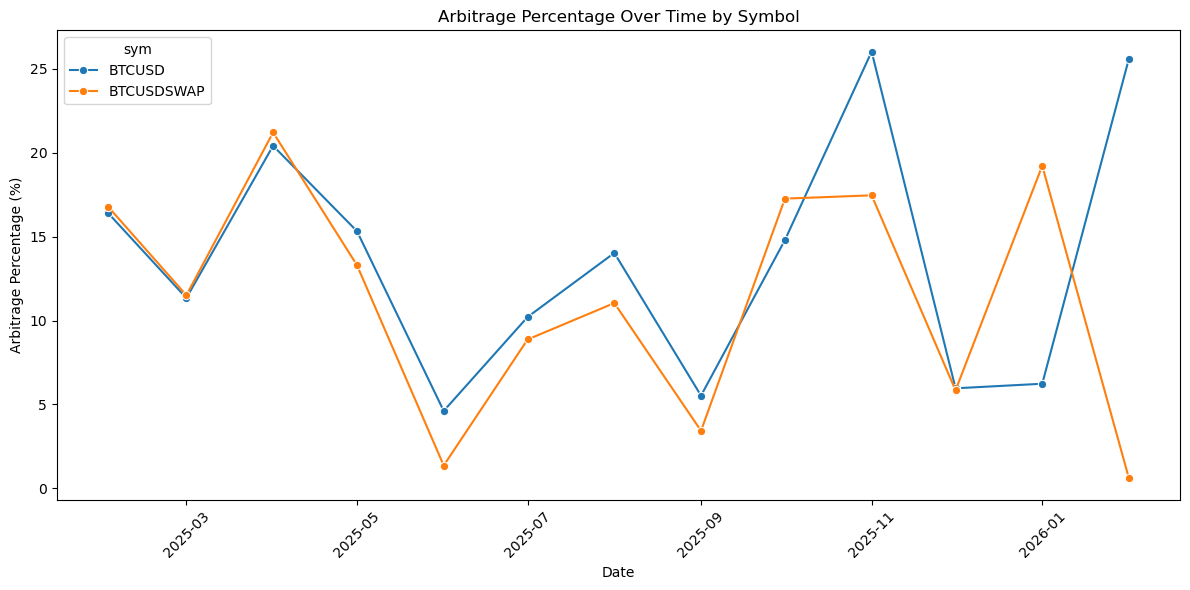

In [85]:
# Determine the average spread over time for each token
plt.figure(figsize=(12, 6))
sns.lineplot(data=arbitrage_stats, x='date', y='arbitrage_pct', hue='sym', marker='o')
plt.title('Arbitrage Percentage Over Time by Symbol')
plt.ylabel('Arbitrage Percentage (%)')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('arbitrage_over_time.png')

C:\Users\sandh\AppData\Local\Temp\ipykernel_62820\3292307124.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\sandh\AppData\Local\Temp\ipykernel_62820\3292307124.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


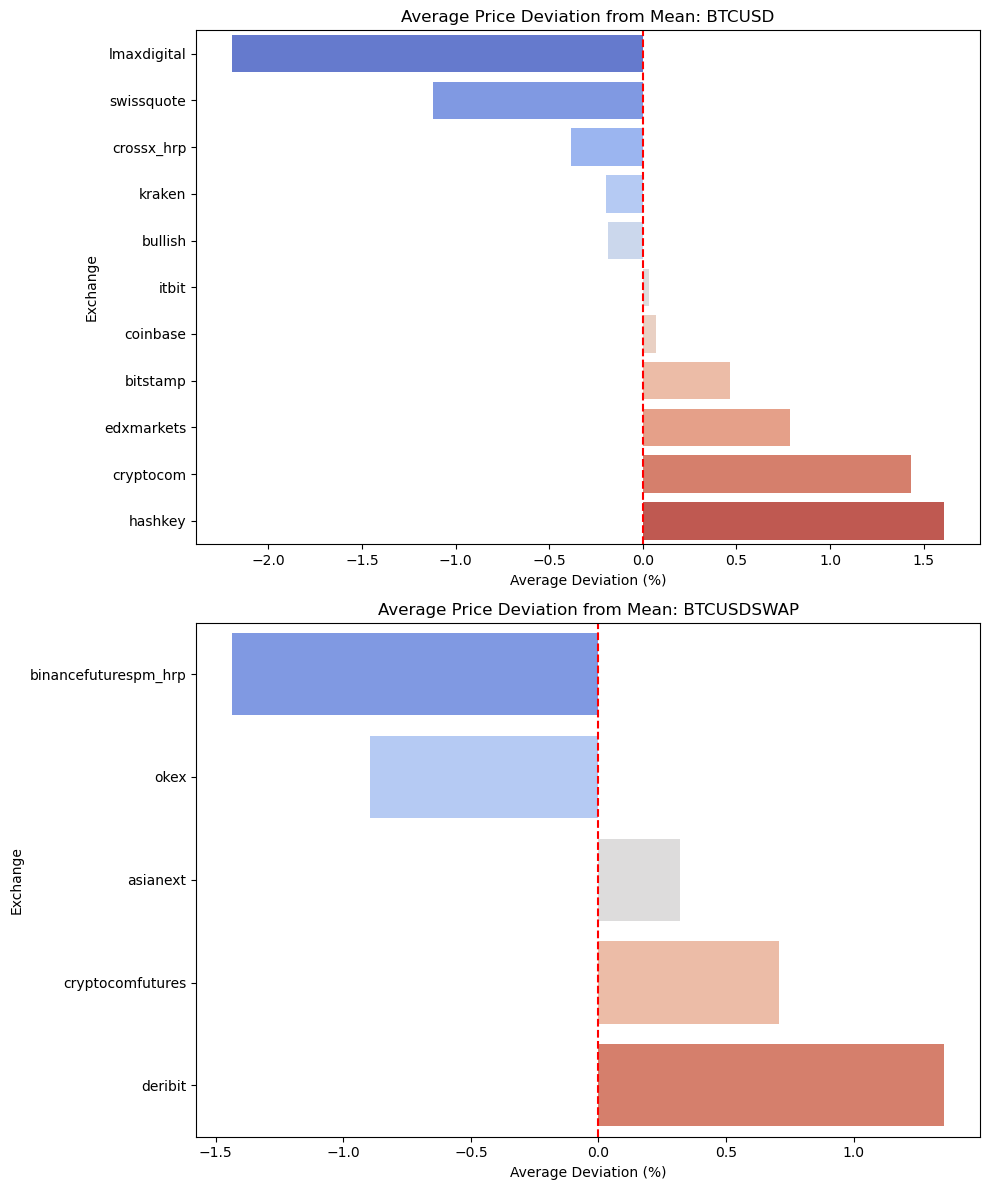

In [97]:
# Determine the difference from the mean for each token for each exchange
# 1. Calculate the average price per specific timestamp and token
avg_prices = data.groupby(['startTime', 'sym'])['lastPrice'].mean().reset_index()
avg_prices.rename(columns={'lastPrice': 'avg_price'}, inplace=True)

# 2. Merge the average prices back and calculate deviation percentage
data_merged = data.merge(avg_prices, on=['startTime', 'sym'])
data_merged['deviation_pct'] = ((data_merged['lastPrice'] - data_merged['avg_price']) / data_merged['avg_price']) * 100

# 3. Group by Token (sym) and Exchange to find the average deviation
avg_dev_token = data_merged.groupby(['sym', 'exchange'])['deviation_pct'].mean().reset_index()

# 4. Visualization: Create subplots for each token
tokens = avg_dev_token['sym'].unique()
fig, axes = plt.subplots(len(tokens), 1, figsize=(10, 6 * len(tokens)))

# Ensure axes is a list/array even if there is only one token
if len(tokens) == 1:
    axes = [axes]

for i, token in enumerate(tokens):
    # Filter and sort data for the current token for a cleaner chart
    token_data = avg_dev_token[avg_dev_token['sym'] == token].sort_values(by='deviation_pct')
    
    sns.barplot(
        data=token_data, 
        y='exchange', 
        x='deviation_pct', 
        ax=axes[i], 
        palette='coolwarm'
    )
    
    # Add a reference line at 0% deviation
    axes[i].axvline(0, color='red', linestyle='--')
    axes[i].set_title(f'Average Price Deviation from Mean: {token}')
    axes[i].set_xlabel('Average Deviation (%)')
    axes[i].set_ylabel('Exchange')

plt.tight_layout()
plt.show()

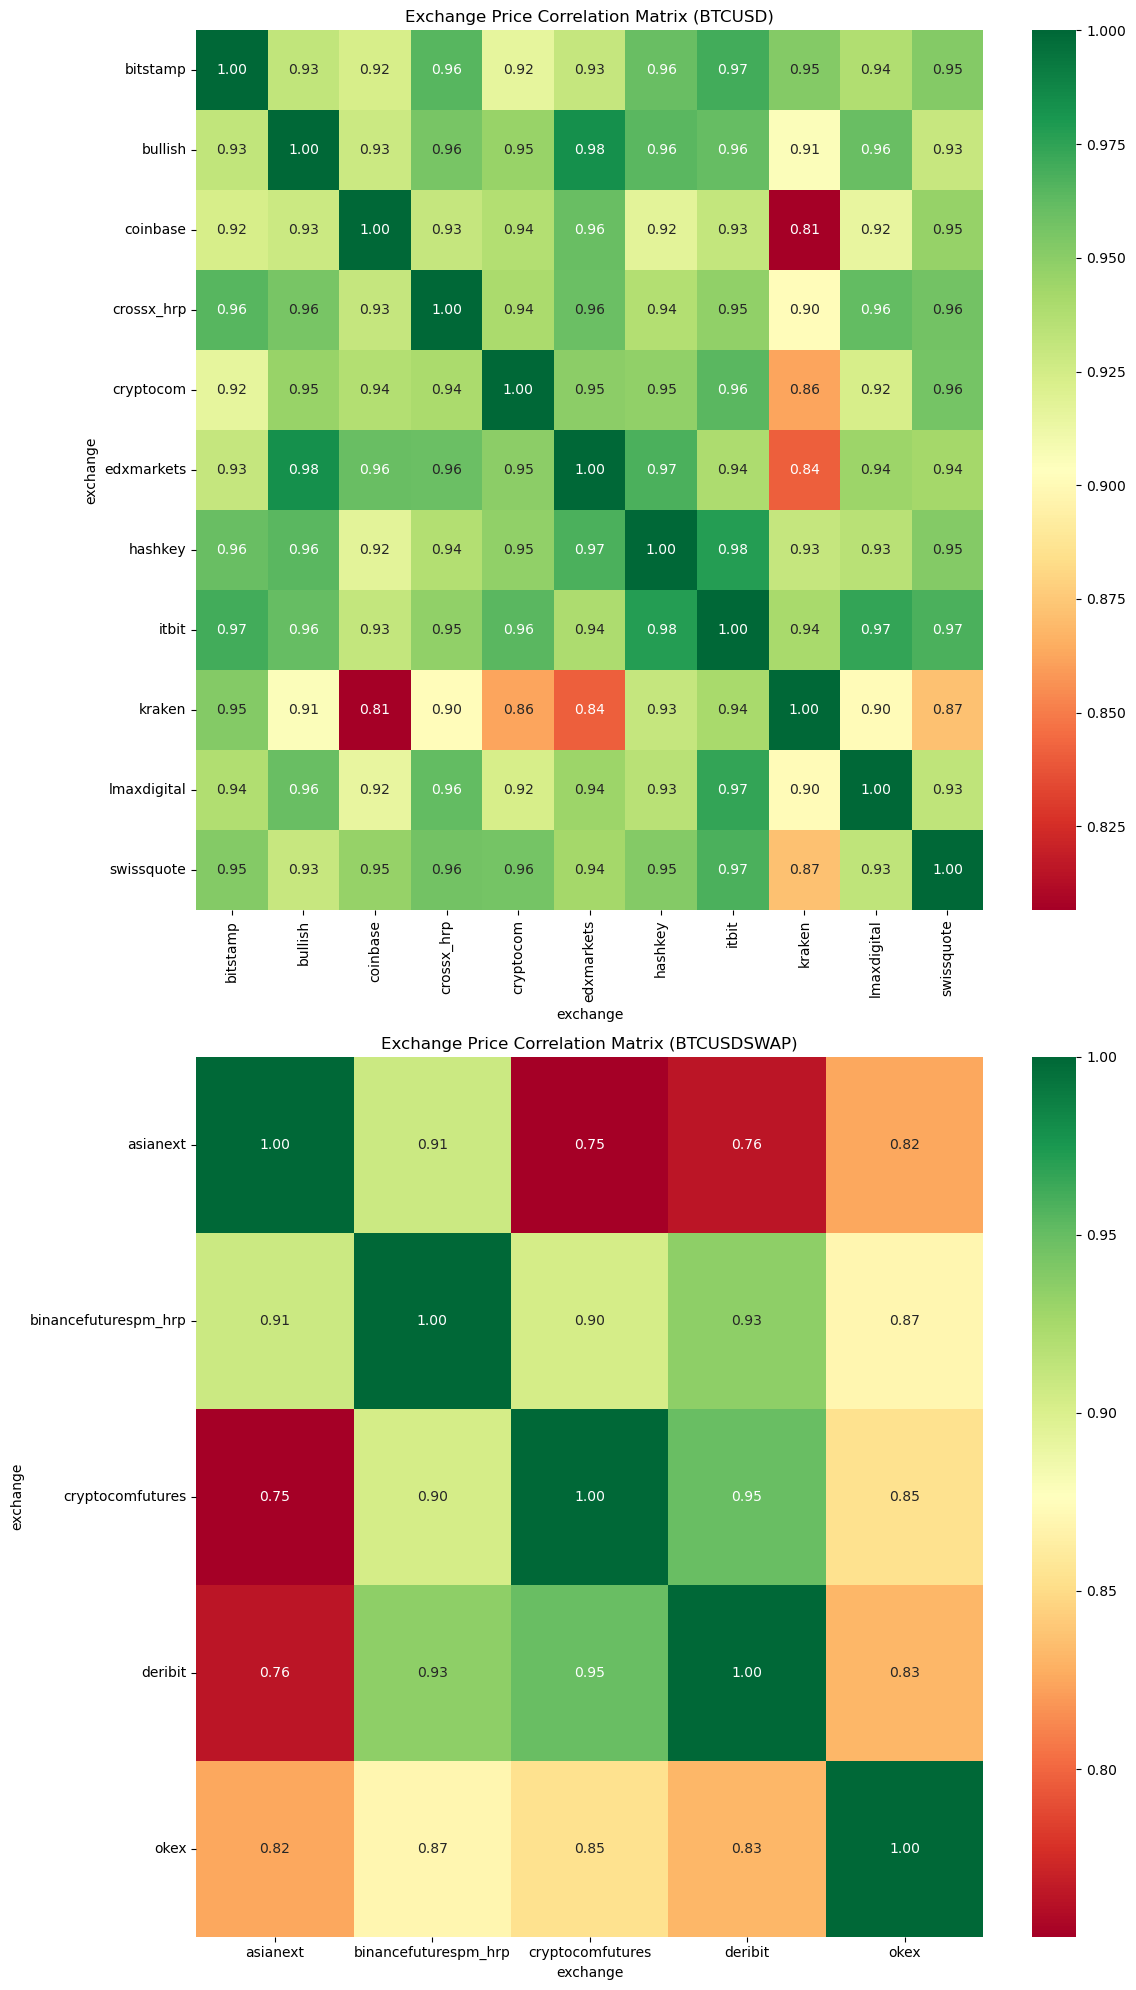

In [101]:
# Obtain correlation matrices for the prices on the exchanges for each token
# 1. Identify unique tokens 
tokens = data['sym'].unique()

# 2. Set up subplots for heatmaps
fig, axes = plt.subplots(len(tokens), 1, figsize=(12, 10 * len(tokens)))

# Handle the case where there might only be one token
if len(tokens) == 1:
    axes = [axes]

for i, token in enumerate(tokens):
    # Pivot data to see prices side-by-side for the specific token
    price_pivot = data[data['sym'] == token].pivot(index='startTime', columns='exchange', values='lastPrice')
    
    # Calculate correlation matrix
    corr_matrix = price_pivot.corr()
    
    # Plot heatmap on the corresponding subplot
    sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', ax=axes[i])
    axes[i].set_title(f'Exchange Price Correlation Matrix ({token})')

plt.tight_layout()
plt.show()

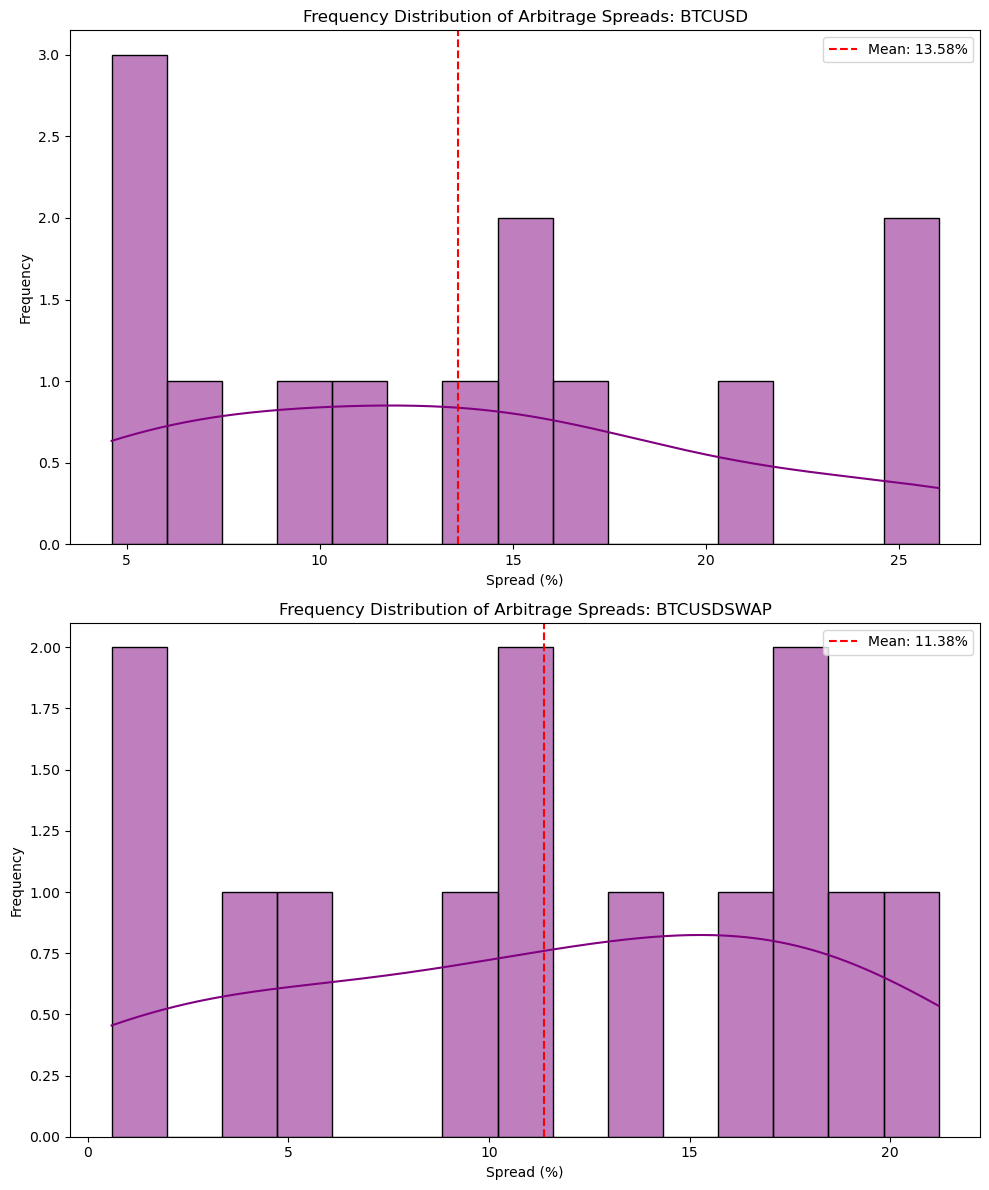

In [105]:
# 1. Calculate arbitrage stats per timestamp and token
arbitrage_stats = data.groupby(['startTime', 'sym']).agg(
    min_price=('lastPrice', 'min'),
    max_price=('lastPrice', 'max')
).reset_index()

arbitrage_stats['arbitrage_pct'] = ((arbitrage_stats['max_price'] - arbitrage_stats['min_price']) / arbitrage_stats['min_price']) * 100

# 2. Get unique tokens (BTCUSD and BTCUSDSWAP)
tokens = arbitrage_stats['sym'].unique()

# 3. Create subplots for each token's distribution
fig, axes = plt.subplots(len(tokens), 1, figsize=(10, 6 * len(tokens)))

# Handle the case where there might only be one token in the list
if len(tokens) == 1:
    axes = [axes]

for i, token in enumerate(tokens):
    token_data = arbitrage_stats[arbitrage_stats['sym'] == token]
    
    # Plot histogram for the specific token
    sns.histplot(token_data['arbitrage_pct'], bins=15, kde=True, color='purple', ax=axes[i])
    
    # Calculate and add the mean vertical line
    mean_val = token_data['arbitrage_pct'].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}%')
    
    # Add titles and labels
    axes[i].set_title(f'Frequency Distribution of Arbitrage Spreads: {token}')
    axes[i].set_xlabel('Spread (%)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [113]:
# 1. Define Capital and Fee Structure
capital = 1000000  # $1 Million capital per arbitrage opportunity
fee_rate = 0.002   # 0.2% of the transaction volume (covering buy + sell)

# 2. Calculate Arbitrage Stats (Gross Spread)
# Grouping by startTime and symbol to find the spread at each moment
arbitrage_stats = data.groupby(['startTime', 'sym']).agg(
    min_price=('lastPrice', 'min'),
    max_price=('lastPrice', 'max')
).reset_index()

arbitrage_stats['gross_spread_pct'] = ((arbitrage_stats['max_price'] - arbitrage_stats['min_price']) / arbitrage_stats['min_price']) * 100

# 3. Apply the 0.2% Transaction Fee
# We calculate the fixed cost in dollars based on the $1M volume
arbitrage_stats['transaction_cost_usd'] = capital * fee_rate
arbitrage_stats['gross_profit_usd'] = capital * (arbitrage_stats['gross_spread_pct'] / 100)
arbitrage_stats['net_profit_usd'] = arbitrage_stats['gross_profit_usd'] - arbitrage_stats['transaction_cost_usd']

# 4. Filter for only profitable trades
arbitrage_stats['is_profitable'] = arbitrage_stats['net_profit_usd'] > 0

# 5. Summary per Token
cost_summary = []
for token in arbitrage_stats['sym'].unique():
    token_data = arbitrage_stats[arbitrage_stats['sym'] == token]
    profitable_trades = token_data[token_data['is_profitable']]
    
    cost_summary.append({
        'Symbol': token,
        'Avg Gross Spread (%)': round(token_data['gross_spread_pct'].mean(), 2),
        'Cost per $1M Trade': f"${int(capital * fee_rate):,}",
        'Avg Net Profit per Trade ($)': round(token_data['net_profit_usd'].mean(), 2),
        'Total Cumulative Net Profit ($)': round(profitable_trades['net_profit_usd'].sum(), 2)
    })

# Display the summary table
summary_df = pd.DataFrame(cost_summary)
print(summary_df)

       Symbol  Avg Gross Spread (%) Cost per $1M Trade  \
0      BTCUSD                 13.58             $2,000   
1  BTCUSDSWAP                 11.38             $2,000   

   Avg Net Profit per Trade ($)  Total Cumulative Net Profit ($)  
0                     133761.96                       1738905.48  
1                     111756.68                       1452836.85  


Key Findings

There is the potential for significant profit through arbitrage. Both BTCUSD and BTCUSDSWAP exhibit arbitrage opportunities. The average gross spread for BTCUSD is 13.58%, while BTCUSDSWAP averages 11.38%. Even after accounting for trading fees (0.1% for each exchange), the net profit remains high (13.38% and 11.18%). 

The best exchanges to buy from are LMAX Digital and Swissquote for BTCUSD and OKEx and AsiaNext for BTCUSDSWAP. These exchanges consistently trade at a discount to the global mean. Note that AsiaNext has a lower correlation with Deribit and Crypto.com. 

The best exchanges to sell from are Kraken and Crypto.com for BTCUSD and Deribit for BTCUSDSWAP. These exchanges more frequently quote lower prices than the mean. Note that Kraken has a lower correlation with coinbase, Edxmarkets and Crypto.com. 

BTCUSD shows higher volatility in spreads than BTCUSDSWAP. This implies that while the latter is slightly more efficient, the former offers higher "alpha" for traders who can move capital quickly between exchanges.

Recommendations

Focus initially on BTCUSD. While both are profitable, the higher average spread (13.58%) provides a larger buffer against slippage and/or increased trading fees.

BTCUSD Strategy: LMAX Digital → Kraken or LMAX Digital → Swissquote strategy.

BTCUSDSWAP Strategy: OKEx → Deribit strategy.

These spreads are significant, the cause is likely capital mobility. Consider keeping "dry powder" (stablecoins or USD) on the buying exchanges (OKEx/LMAX) and the target asset on the selling exchanges to execute "instant" arbitrage without waiting for cross-exchange transfers.

Further points to consider

Are prices low on certain exchanges because users cannot easily move funds out?

Are these prices available for large volumes or just small trades?

Note. It is assumed that liquidity is not an issue here when executing this strategy. 